# Inertia Forecasting — Cardinality-Constrained Sparse Regression
## Nordic · GB · ERCOT Power Systems (2021)

**Pipeline:** Feature engineering → Temporal 70/15/15 train/val/test split → K-fold CV (TimeSeriesSplit) for sparsity tuning → Gurobi MIQP → Statistical evaluation.

$$\min_{\beta_0,\boldsymbol{\beta},\mathbf{z}}\;\sum_{t=1}^{T}\!\left(I_t - \beta_0 - \boldsymbol{\beta}^\top\boldsymbol{\phi}_t\right)^2\quad\text{s.t.}\quad\textstyle\sum_j z_j \le K,\;{-M_\beta z_j \le \beta_j \le M_\beta z_j},\;z_j\in\{0,1\}$$

In [11]:
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '/home/alireza/Desktop/inertia'

plt.rcParams.update({
    'font.family':        'serif',
    'font.serif':         ['DejaVu Serif', 'Times New Roman'],
    'font.size':          11,
    'axes.labelsize':     12,
    'axes.titlesize':     12,
    'axes.titleweight':   'bold',
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'legend.fontsize':    10,
    'legend.framealpha':  0.9,
    'legend.edgecolor':   '0.8',
    'figure.dpi':         120,
    'axes.grid':          True,
    'grid.alpha':         0.25,
    'grid.linestyle':     '--',
    'grid.linewidth':     0.6,
    'lines.linewidth':    1.8,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.linewidth':     0.8,
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
    'savefig.pad_inches': 0.05,
})

PALETTE  = {'ERCOT': '#1565C0', 'GB': '#B71C1C', 'Nordic': '#1B5E20'}
PALETTE2 = {'ERCOT': '#90CAF9', 'GB': '#EF9A9A', 'Nordic': '#A5D6A7'}
MARKERS  = {'ERCOT': 'o', 'GB': 's', 'Nordic': '^'}
print('Environment ready.')

Environment ready.


## 1 · Data Loading

In [21]:
def load_system(name):
    files = {'ERCOT':'ercot_inertia.csv','GB':'inertia_GB.csv','Nordic':'inertia_nordic.csv'}
    df = pd.read_csv(f"{DATA_DIR}/{files[name]}")
    df['time'] = pd.to_datetime(df['time'])
    if 'forecast_other_genration' in df.columns:
        df = df.rename(columns={'forecast_other_genration':'forecast_other_generation'})
    if name in ('GB','Nordic'):
        df['inertia'] = df['inertia'] * 1e3
    key_cols = ['inertia','forecast_load','forecast_wind','forecast_solar','forecast_other_generation']
    return df.dropna(subset=key_cols).reset_index(drop=True)

systems = {n: load_system(n) for n in ['ERCOT','GB','Nordic']}
print(f"{'System':<8} {'Rows':>6}  {'Min (MWs)':>14}  {'Max (MWs)':>14}  Date range")
print('-'*72)
for n, df in systems.items():
    print(f"{n:<8} {len(df):>6}  {df.inertia.min():>14,.0f}  "
          f"{df.inertia.max():>14,.0f}  "
          f"{df.time.min().date()} to {df.time.max().date()}")

System     Rows       Min (MWs)       Max (MWs)  Date range
------------------------------------------------------------------------
ERCOT      8751         109,599         381,261  2021-01-01 to 2022-01-01
GB         7864         131,000         380,000  2020-06-01 to 2021-05-31
Nordic     8653         110,000         256,000  2021-01-01 to 2021-12-31


## 2 · Feature Engineering

Candidate feature vector $\boldsymbol{\phi}_t \in \mathbb{R}^{24}$ ($p=24$):

| Group | Features | Count |
|---|---|---|
| Load family | $P^L$, $(P^L)^2$, $\sqrt{P^L}$, $\log P^L$ | 4 |
| Wind family | same 4 transforms of $P^W$ | 4 |
| Solar family | same 4 transforms of $P^S$ | 4 |
| Other-gen family | same 4 transforms of $P^O$ | 4 |
| Calendar | $\sin/\cos$ of hour, day-of-week, month | 6 |
| AR lags | $I_{t-1}$, $I_{t-24}$ | 2 |

In [23]:
def build_features(df, eps=1.0):
    t     = df['time']
    I_raw = df['inertia'].values.astype(float)
    base_vars = {
        'load':      df['forecast_load'].values.clip(0),
        'wind':      df['forecast_wind'].values.clip(0),
        'solar':     df['forecast_solar'].values.clip(0),
        'other_gen': df['forecast_other_generation'].values.clip(0),
    }
    cols, names, groups, transform_sets = [], [], {}, []
    for var_name, x in base_vars.items():
        g_idx, t_idx = [], []
        for suffix, arr in [(var_name, x), (f'{var_name}^2', x**2),
                            (f'sqrt_{var_name}', np.sqrt(x)),
                            (f'log_{var_name}', np.log(x + eps))]:
            cols.append(arr); names.append(suffix)
            idx = len(cols)-1; g_idx.append(idx); t_idx.append(idx)
        groups[f'G_{var_name}'] = g_idx
        transform_sets.append(t_idx)
    hour = t.dt.hour.values; dow = t.dt.dayofweek.values; month = t.dt.month.values
    cal_s = len(cols)
    for suffix, arr in [('sin_hour', np.sin(2*np.pi*hour/24)),
                        ('cos_hour', np.cos(2*np.pi*hour/24)),
                        ('sin_dow',  np.sin(2*np.pi*dow/7)),
                        ('cos_dow',  np.cos(2*np.pi*dow/7)),
                        ('sin_month',np.sin(2*np.pi*month/12)),
                        ('cos_month',np.cos(2*np.pi*month/12))]:
        cols.append(arr); names.append(suffix)
    groups['G_calendar'] = list(range(cal_s, len(cols)))
    lag_s = len(cols)
    Is = pd.Series(I_raw)
    cols.append(Is.shift(1).bfill().values);  names.append('I_lag1')
    cols.append(Is.shift(24).bfill().values); names.append('I_lag24')
    groups['G_lags'] = list(range(lag_s, len(cols)))
    return np.column_stack(cols).astype(float), I_raw, names, groups, transform_sets

feat_data = {}
for sname in systems:
    Phi, I_vec, feat_names, grps, tsets = build_features(systems[sname])
    feat_data[sname] = dict(Phi=Phi, I_vec=I_vec, feat_names=feat_names,
                            groups=grps, transform_sets=tsets)
    print(f"{sname}: shape={Phi.shape}")

ERCOT: shape=(8751, 24)
GB: shape=(7864, 24)
Nordic: shape=(8653, 24)


## 3 · Temporal Train / Validation / Test Split

| Split | Fraction | Role |
|---|---|---|
| **Train** | 70% | Fit MIQP coefficients |
| **Validation** | 15% | Independent generalisation check |
| **Test** | 15% | One-shot final evaluation (never used during tuning) |

$K^\star$ is selected by minimising the mean CV-RMSE across 3 `TimeSeriesSplit` folds on the **training** set only.

In [24]:
TRAIN_FRAC, VAL_FRAC = 0.70, 0.15

splits = {}
for sname in systems:
    d = feat_data[sname]
    T = len(d['I_vec'])
    n_tr  = int(T * TRAIN_FRAC)
    n_val = int(T * VAL_FRAC)
    splits[sname] = {
        'Phi_tr': d['Phi'][:n_tr],           'I_tr': d['I_vec'][:n_tr],
        'Phi_va': d['Phi'][n_tr:n_tr+n_val], 'I_va': d['I_vec'][n_tr:n_tr+n_val],
        'Phi_te': d['Phi'][n_tr+n_val:],     'I_te': d['I_vec'][n_tr+n_val:],
        'n_tr': n_tr, 'n_val': n_val, 'n_te': T-n_tr-n_val, 'T': T,
        'time': systems[sname]['time'].values,
    }
    print(f"{sname}: train={n_tr}  val={n_val}  test={T-n_tr-n_val}  total={T}")

ERCOT: train=6125  val=1312  test=1314  total=8751
GB: train=5504  val=1179  test=1181  total=7864
Nordic: train=6057  val=1297  test=1299  total=8653


## 4 · MIQP Solver (Eqs 7–10)

In [25]:
def fit_miqp(Phi_tr, I_tr, K=5, M_beta=10.0, time_limit=60.0, verbose=False):
    T, p   = Phi_tr.shape
    phi_mu = Phi_tr.mean(0); phi_sg = Phi_tr.std(0).clip(1e-8)
    I_mu   = I_tr.mean();    I_sg   = I_tr.std()
    Phis   = (Phi_tr - phi_mu) / phi_sg
    Is     = (I_tr  - I_mu)   / I_sg
    Phi_aug = np.column_stack([np.ones(T), Phis])
    Q = Phi_aug.T @ Phi_aug
    c = -2.0 * (Phi_aug.T @ Is)
    m = gp.Model('miqp')
    m.Params.OutputFlag   = int(verbose)
    m.Params.TimeLimit    = time_limit
    m.Params.MIPGap       = 1e-4
    m.Params.NumericFocus = 1
    theta = m.addMVar(p+1, lb=-GRB.INFINITY, name='theta')
    z     = m.addMVar(p,   vtype=GRB.BINARY,  name='z')
    m.setObjective(theta @ Q @ theta + c @ theta, GRB.MINIMIZE)
    m.addConstr(z.sum()    <= K,          name='card')
    m.addConstr(theta[1:] <=  M_beta * z, name='bigM_u')
    m.addConstr(theta[1:] >= -M_beta * z, name='bigM_l')
    m.optimize()
    if m.Status not in (GRB.OPTIMAL, GRB.TIME_LIMIT, GRB.SUBOPTIMAL): return None
    th    = theta.X
    beta  = I_sg * th[1:] / phi_sg
    beta0 = I_mu + I_sg*th[0] - (beta * phi_mu).sum()
    return {'beta0': beta0, 'beta': beta,
            'selected': np.where(z.X.round()==1)[0],
            'status': m.Status, 'mip_gap': m.MIPGap}


def predict(Phi, p): return p['beta0'] + Phi @ p['beta']


def metrics(I_true, I_hat):
    res   = I_true - I_hat
    rmse  = np.sqrt((res**2).mean())
    mae   = np.abs(res).mean()
    mape  = (np.abs(res) / np.abs(I_true).clip(1)).mean() * 100
    r2    = 1 - (res**2).sum() / ((I_true-I_true.mean())**2).sum()
    nrmse = rmse / I_true.mean() * 100
    return dict(rmse=rmse, mae=mae, mape=mape, r2=r2, nrmse=nrmse, res=res, I_hat=I_hat)

print('Solver and metric utilities defined.')

Solver and metric utilities defined.


## 5 · Sparsity Tuning via K-Fold Cross-Validation

For each $K \in \{1,\ldots,15\}$ and each system, **3-fold `TimeSeriesSplit`** (expanding window) is run on the training set. The fold-averaged validation RMSE identifies $K^\star = \arg\min_K \overline{\text{RMSE}}_{\text{CV}}(K)$.

In [26]:
K_RANGE  = list(range(1, 16))
N_SPLITS = 3
M_BETA   = 10.0
TL_CV    = 45.0
TL_FINAL = 120.0

cv_records = {}

for sname in ['ERCOT','GB','Nordic']:
    print(f"\n{'=':=>56}")
    print(f"  {sname}  |  K-fold CV  (n_splits={N_SPLITS})")
    print(f"{'=':=>56}")
    Phi_tr = splits[sname]['Phi_tr']; I_tr = splits[sname]['I_tr']
    tscv   = TimeSeriesSplit(n_splits=N_SPLITS)
    cv_m, cv_s, tr_r = [], [], []

    for K in K_RANGE:
        fold_rmse = []
        for fi, vi in tscv.split(Phi_tr):
            p = fit_miqp(Phi_tr[fi], I_tr[fi], K=K, M_beta=M_BETA, time_limit=TL_CV)
            if p is None:
                fold_rmse.append(np.nan); continue
            fold_rmse.append(np.sqrt(((I_tr[vi] - predict(Phi_tr[vi], p))**2).mean()))
        p_full = fit_miqp(Phi_tr, I_tr, K=K, M_beta=M_BETA, time_limit=TL_CV)
        tr_rmse = (np.sqrt(((I_tr - predict(Phi_tr, p_full))**2).mean())
                   if p_full is not None else np.nan)
        cv_m.append(np.nanmean(fold_rmse))
        cv_s.append(np.nanstd(fold_rmse))
        tr_r.append(tr_rmse)
        print(f"  K={K:2d}  CV RMSE={cv_m[-1]/1e3:6.2f} +/- {cv_s[-1]/1e3:.2f} GWs  "
              f"Train RMSE={tr_r[-1]/1e3:6.2f} GWs")

    cv_records[sname] = {'k': K_RANGE, 'cv_mean': cv_m, 'cv_std': cv_s, 'train_rmse': tr_r}

print('\nCV sweep complete.')


  ERCOT  |  K-fold CV  (n_splits=3)
  K= 1  CV RMSE=  8.40 +/- 1.25 GWs  Train RMSE=  7.73 GWs
  K= 2  CV RMSE=  7.03 +/- 0.28 GWs  Train RMSE=  6.17 GWs
  K= 3  CV RMSE=  6.94 +/- 0.33 GWs  Train RMSE=  6.01 GWs
  K= 4  CV RMSE=  6.87 +/- 0.24 GWs  Train RMSE=  5.91 GWs
  K= 5  CV RMSE=  6.67 +/- 0.11 GWs  Train RMSE=  5.79 GWs
  K= 6  CV RMSE=  6.66 +/- 0.08 GWs  Train RMSE=  5.75 GWs
  K= 7  CV RMSE=  6.65 +/- 0.03 GWs  Train RMSE=  5.73 GWs
  K= 8  CV RMSE=  6.74 +/- 0.09 GWs  Train RMSE=  5.70 GWs
  K= 9  CV RMSE=  6.63 +/- 0.06 GWs  Train RMSE=  5.68 GWs
  K=10  CV RMSE=  6.63 +/- 0.05 GWs  Train RMSE=  5.68 GWs
  K=11  CV RMSE=  6.79 +/- 0.21 GWs  Train RMSE=  5.67 GWs
  K=12  CV RMSE=  6.79 +/- 0.21 GWs  Train RMSE=  5.67 GWs
  K=13  CV RMSE=  6.82 +/- 0.19 GWs  Train RMSE=  5.66 GWs
  K=14  CV RMSE=  6.80 +/- 0.23 GWs  Train RMSE=  5.66 GWs
  K=15  CV RMSE=  6.83 +/- 0.36 GWs  Train RMSE=  5.66 GWs

  GB  |  K-fold CV  (n_splits=3)
  K= 1  CV RMSE= 14.74 +/- 2.37 GWs  Train R

## 6 · Estimation Error vs Sparsity ($K$)

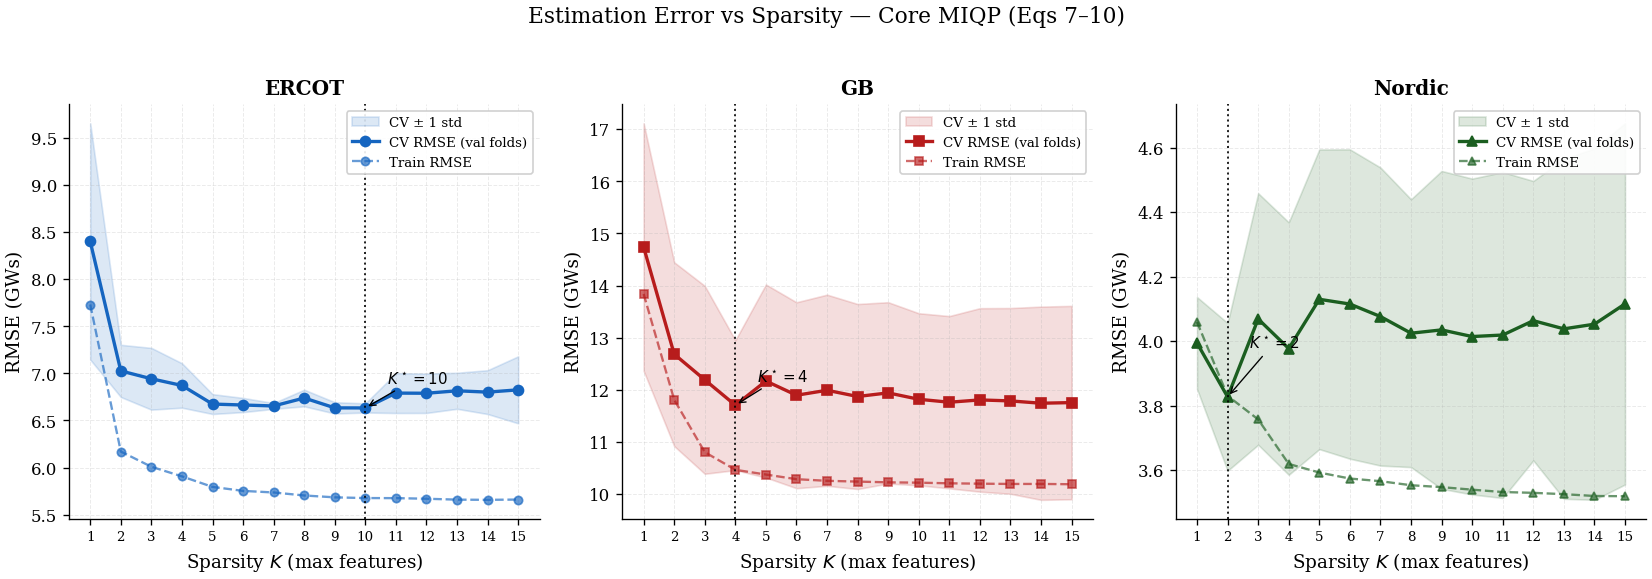

Optimal K per system: {'ERCOT': 10, 'GB': 4, 'Nordic': 2}


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
best_K = {}

for ax, sname in zip(axes, ['ERCOT','GB','Nordic']):
    rec  = cv_records[sname]
    ks   = rec['k']
    cv_m = np.array(rec['cv_mean'])   / 1e3
    cv_s = np.array(rec['cv_std'])    / 1e3
    tr_r = np.array(rec['train_rmse'])/ 1e3
    K_star = ks[int(np.nanargmin(cv_m))]
    best_K[sname] = K_star

    ax.fill_between(ks, cv_m - cv_s, cv_m + cv_s,
                    color=PALETTE[sname], alpha=0.15, label='CV \u00b1 1 std')
    ax.plot(ks, cv_m, color=PALETTE[sname], marker=MARKERS[sname],
            markersize=6, linewidth=2.0, label='CV RMSE (val folds)')
    ax.plot(ks, tr_r, color=PALETTE[sname], marker=MARKERS[sname],
            markersize=5, linewidth=1.4, linestyle='--', alpha=0.65,
            label='Train RMSE')
    ax.axvline(K_star, color='k', linewidth=1.2, linestyle=':', alpha=0.85)
    y_ann = cv_m[K_star-1]
    ax.annotate(
        f'$K^\\star={K_star}$',
        xy=(K_star, y_ann), xytext=(K_star + 0.7, y_ann * 1.04),
        fontsize=9, color='k',
        arrowprops=dict(arrowstyle='->', color='k', lw=0.8))
    ax.set_xlabel('Sparsity $K$ (max features)', fontsize=11)
    ax.set_ylabel('RMSE (GWs)', fontsize=11)
    ax.set_title(sname, fontsize=12)
    ax.set_xticks(ks)
    ax.tick_params(axis='x', labelsize=8)
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle('Estimation Error vs Sparsity \u2014 Core MIQP (Eqs 7\u201310)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/error_vs_sparsity.png')
plt.show()
print(f'Optimal K per system: {best_K}')

## 7 · Final Model: Fit on Train, Evaluate on Test

Using $K^\star$ from CV, fit the MIQP on the **full training set**. Metrics are reported for train, validation, and test — the test set was **never** used during tuning.

In [28]:
final_params = {}
all_metrics  = {}

for sname in ['ERCOT','GB','Nordic']:
    K_star = best_K[sname]
    sp     = splits[sname]
    print(f"\n{'='*56}\n  {sname}  |  K*={K_star}\n{'='*56}")

    p = fit_miqp(sp['Phi_tr'], sp['I_tr'], K=K_star,
                 M_beta=M_BETA, time_limit=TL_FINAL, verbose=False)
    final_params[sname] = p

    m_tr = metrics(sp['I_tr'], predict(sp['Phi_tr'], p))
    m_va = metrics(sp['I_va'], predict(sp['Phi_va'], p))
    m_te = metrics(sp['I_te'], predict(sp['Phi_te'], p))
    all_metrics[sname] = {'train': m_tr, 'val': m_va, 'test': m_te}

    fn = feat_data[sname]['feat_names']
    for split_name, m in [('Train', m_tr), ('Val', m_va), ('Test', m_te)]:
        print(f"  {split_name:<5}  RMSE={m['rmse']/1e3:7.2f} GWs  "
              f"MAE={m['mae']/1e3:6.2f} GWs  MAPE={m['mape']:5.2f}%  "
              f"NRMSE={m['nrmse']:5.2f}%  R2={m['r2']:.4f}")
    print(f"  MIP gap : {p['mip_gap']:.2e}")
    print(f"  Selected ({len(p['selected'])}/{K_star}):")
    for j in p['selected']:
        print(f"    [{j:2d}] {fn[j]:<22} beta={p['beta'][j]:+.4e}")


  ERCOT  |  K*=10
  Train  RMSE=   5.68 GWs  MAE=  4.19 GWs  MAPE= 1.84%  NRMSE= 2.30%  R2=0.9925
  Val    RMSE=   6.92 GWs  MAE=  4.98 GWs  MAPE= 2.21%  NRMSE= 2.88%  R2=0.9792
  Test   RMSE=   6.70 GWs  MAE=  5.07 GWs  MAPE= 2.63%  NRMSE= 3.38%  R2=0.9678
  MIP gap : 9.10e-05
  Selected (10/10):
    [ 3] log_load               beta=-6.4271e+03
    [ 8] solar                  beta=-2.3647e+00
    [ 9] solar^2                beta=+4.2623e-04
    [11] log_solar              beta=+6.0497e+02
    [12] other_gen              beta=+4.3128e-01
    [16] sin_hour               beta=+3.0023e+03
    [17] cos_hour               beta=-4.1041e+03
    [20] sin_month              beta=-1.6076e+03
    [22] I_lag1                 beta=+9.0357e-01
    [23] I_lag24                beta=+1.1850e-02

  GB  |  K*=4
  Train  RMSE=  10.47 GWs  MAE=  7.67 GWs  MAPE= 3.55%  NRMSE= 4.60%  R2=0.9653
  Val    RMSE=  10.21 GWs  MAE=  7.59 GWs  MAPE= 3.33%  NRMSE= 4.33%  R2=0.9658
  Test   RMSE=  10.68 GWs  MAE=  8.

## 8 · Statistical Evaluation Plots

Per-system **2×3 panel** figure:

| Position | Content |
|---|---|
| Top row (full width) | Time series across all splits (train/val/test shaded) |
| Bottom-left | Actual vs Predicted scatter — test set + identity line + inset coefficient chart |
| Bottom-centre | Residuals vs Fitted values (with rolling std envelope) |
| Bottom-right | Normal Q–Q plot of standardised test residuals |

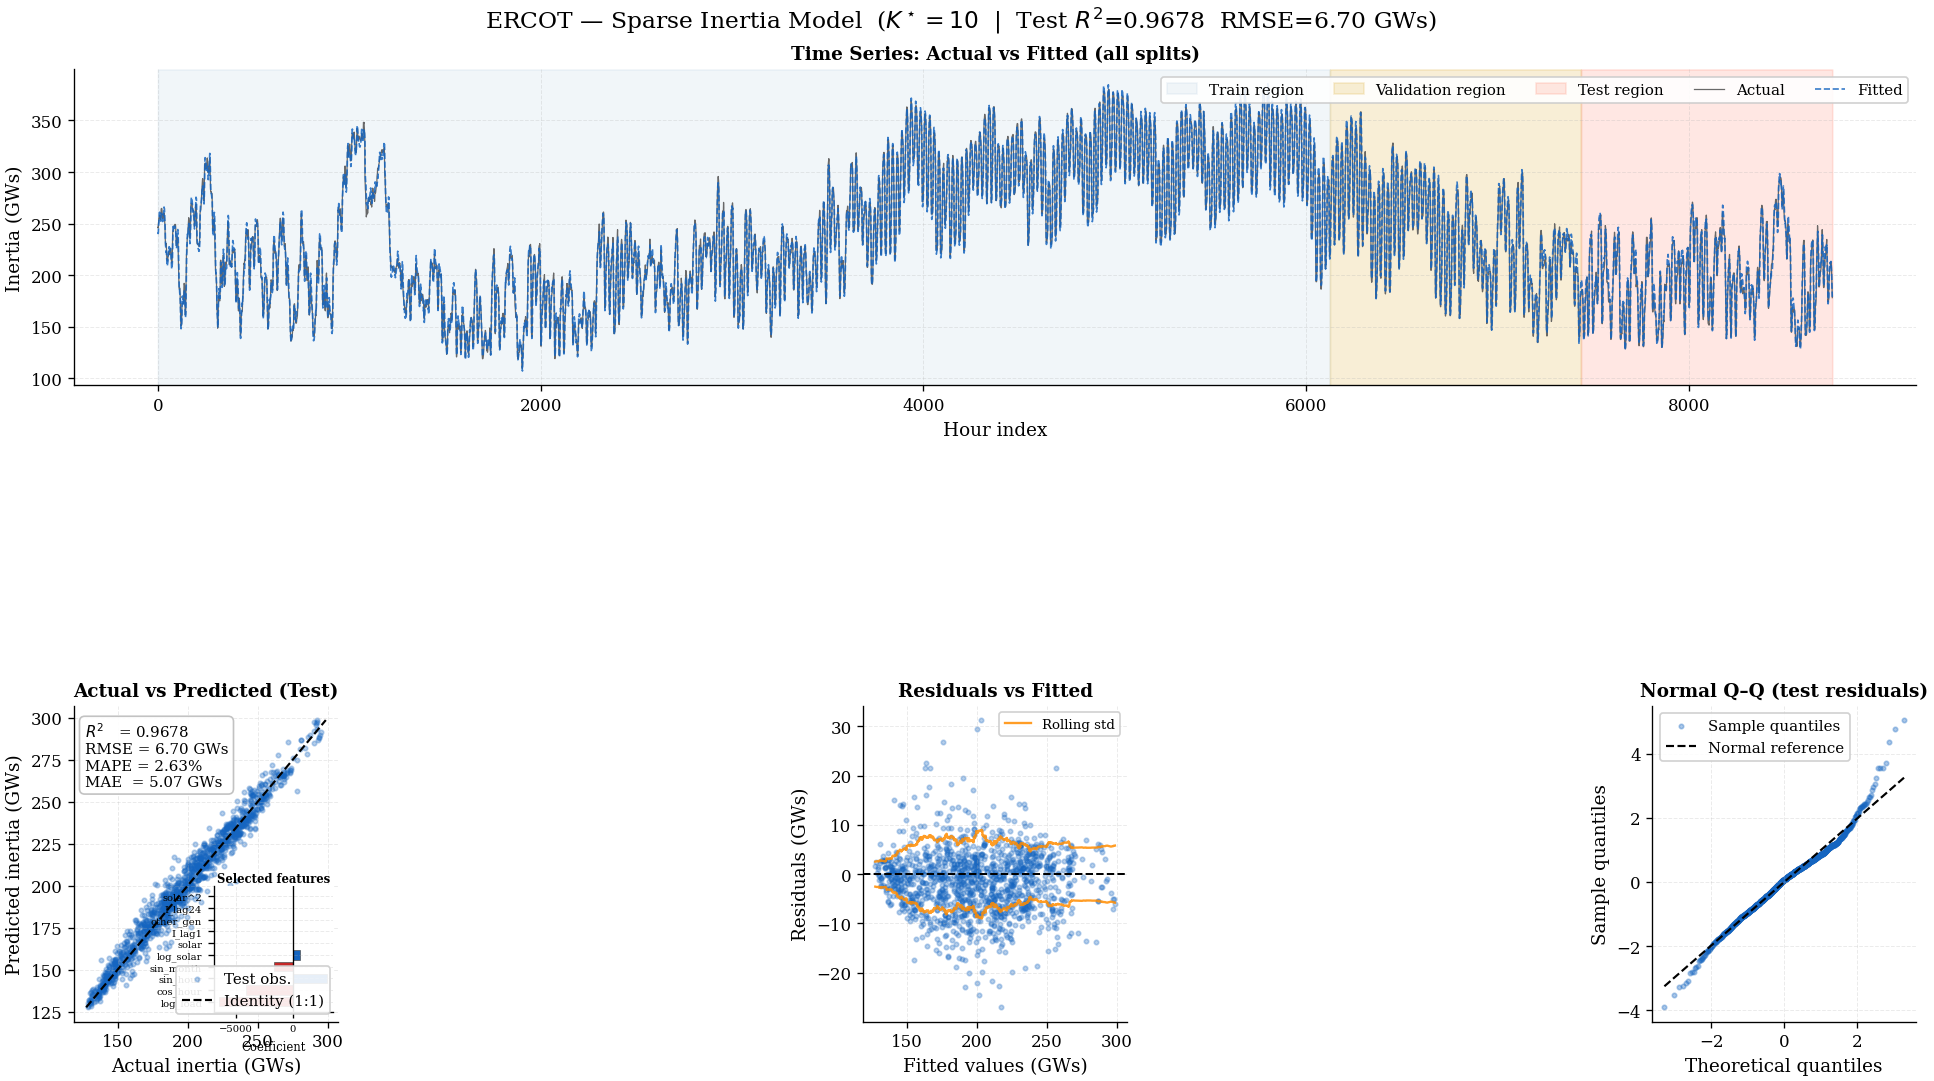

  eval_ERCOT.png saved


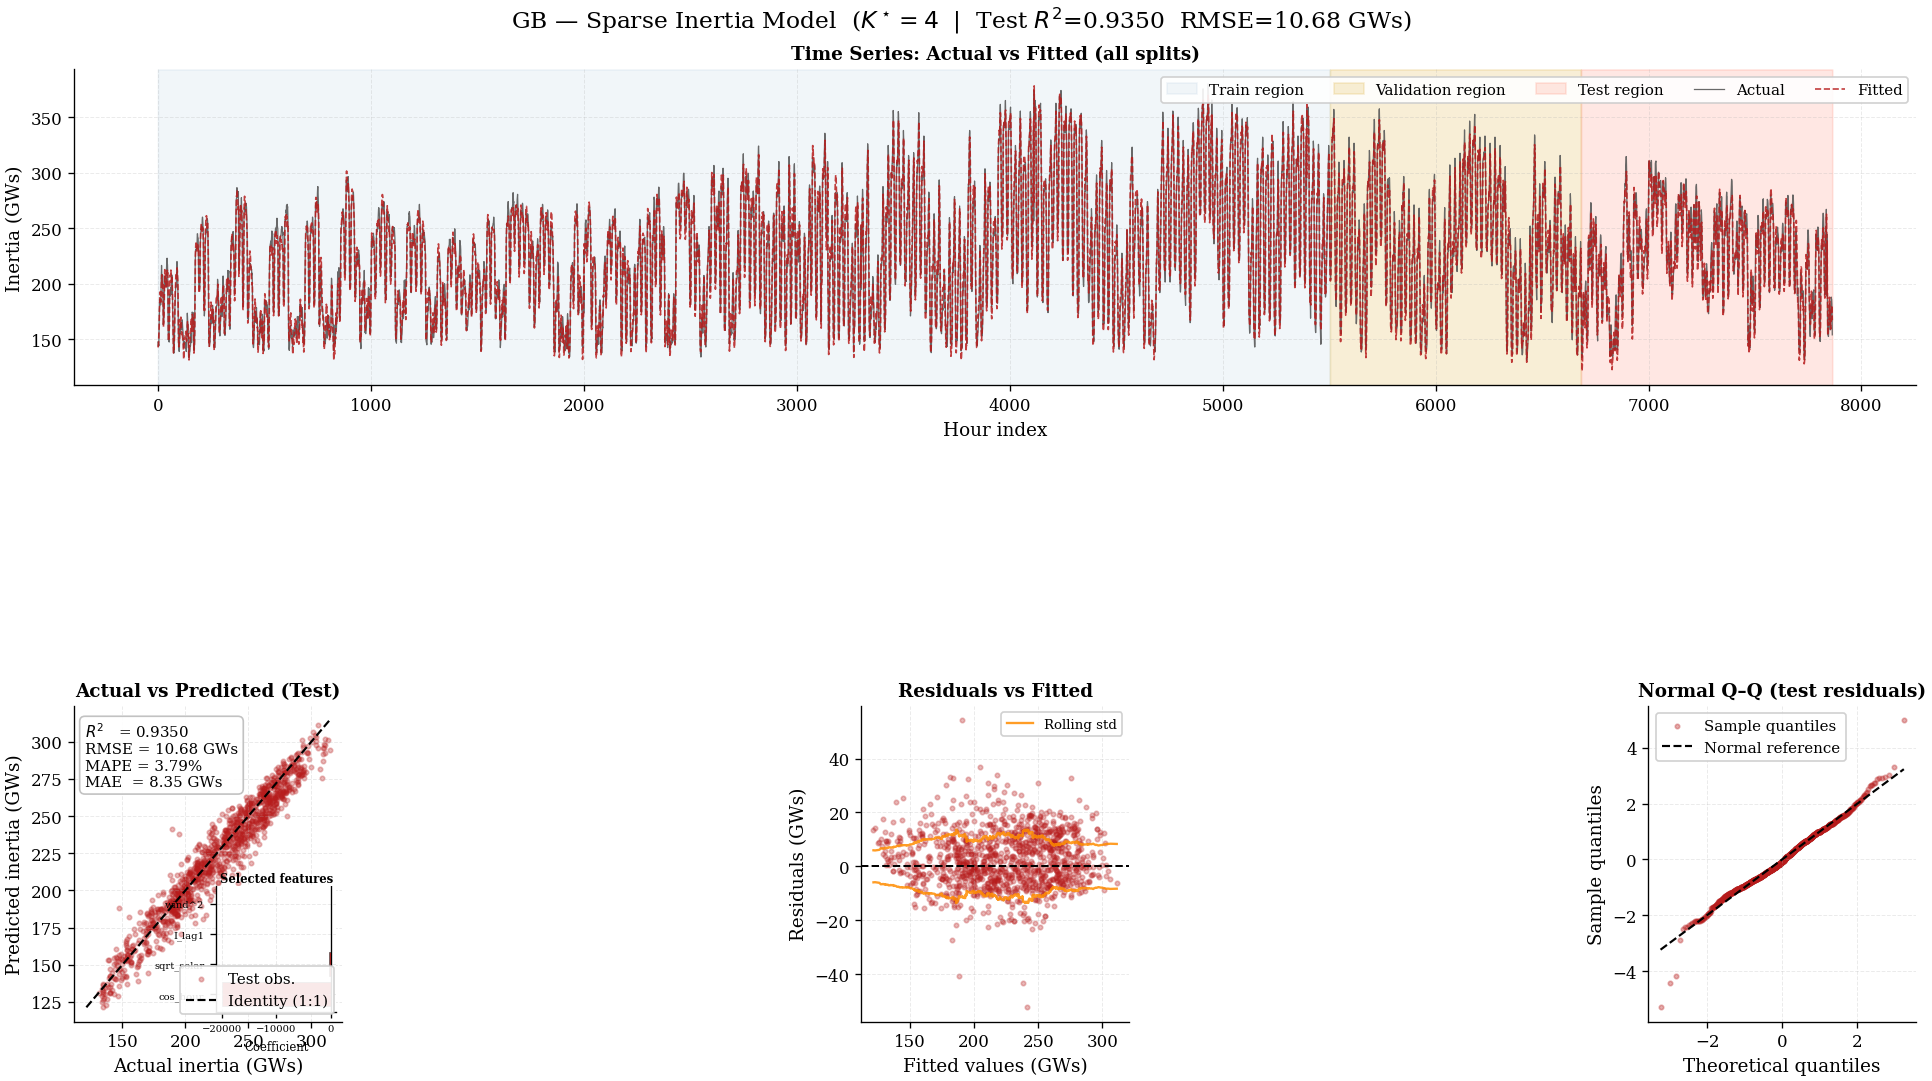

  eval_GB.png saved


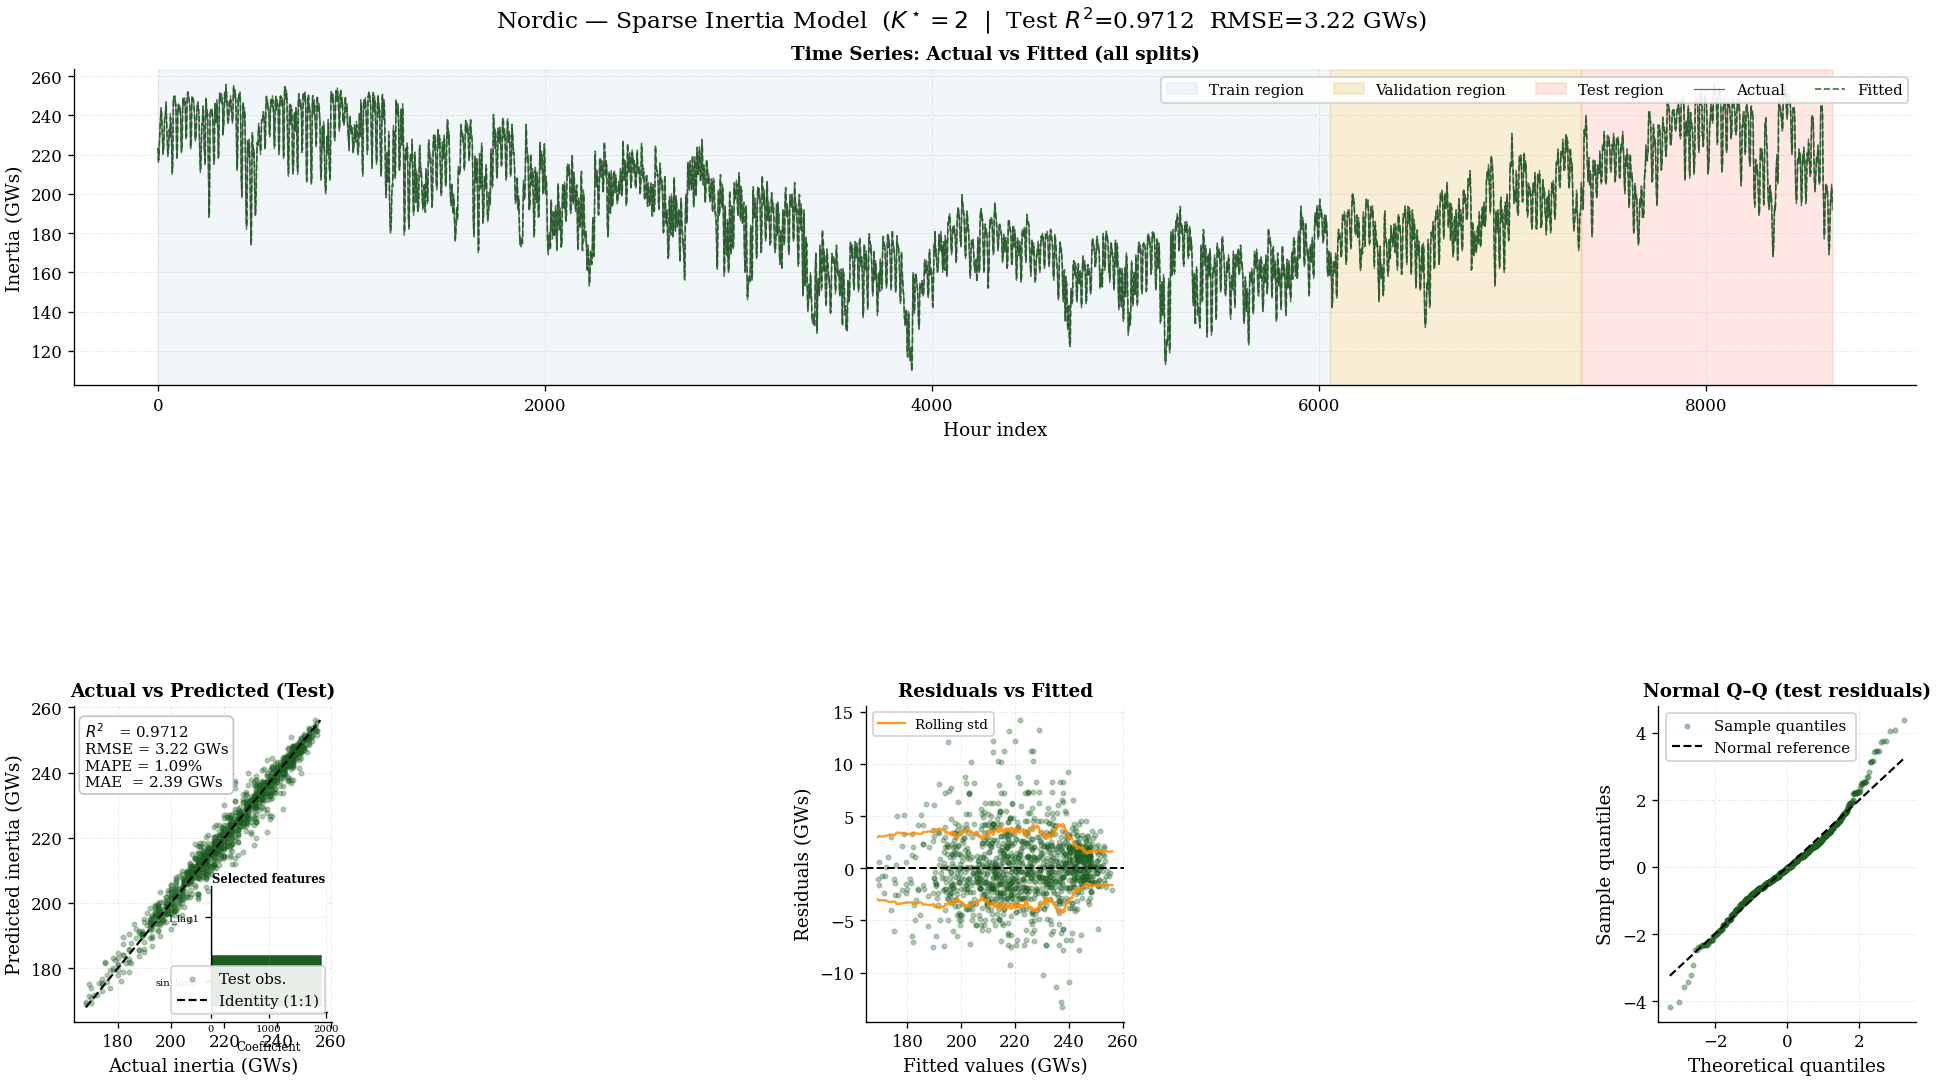

  eval_Nordic.png saved


In [29]:
def make_eval_figure(sname):
    sp   = splits[sname]
    p    = final_params[sname]
    m_te = all_metrics[sname]['test']
    m_tr = all_metrics[sname]['train']
    m_va = all_metrics[sname]['val']
    fn   = feat_data[sname]['feat_names']
    col  = PALETTE[sname]

    I_all   = np.concatenate([sp['I_tr'],     sp['I_va'],     sp['I_te']])
    I_hat_a = np.concatenate([m_tr['I_hat'],   m_va['I_hat'],  m_te['I_hat']])
    n_tr, n_va = sp['n_tr'], sp['n_val']

    sel       = p['selected']
    betas     = p['beta'][sel]
    snames_ft = [fn[j] for j in sel]
    order     = np.argsort(np.abs(betas))[::-1]

    fig = plt.figure(figsize=(16, 9), constrained_layout=True)
    fig.suptitle(
        f'{sname} \u2014 Sparse Inertia Model  '
        f'($K^\\star={len(sel)}$  |  '
        f'Test $R^2$={m_te["r2"]:.4f}  '
        f'RMSE={m_te["rmse"]/1e3:.2f} GWs)',
        fontsize=14)

    gs  = gridspec.GridSpec(2, 3, figure=fig,
                            height_ratios=[1.0, 1.0], hspace=0.45, wspace=0.35)

    # ── Top row: time series ───────────────────────────────────────────────
    ax0 = fig.add_subplot(gs[0, :])
    t   = np.arange(len(I_all))
    ax0.fill_between(t, 0, 1, where=(t < n_tr),
                     transform=ax0.get_xaxis_transform(),
                     color='steelblue', alpha=0.07, label='Train region')
    ax0.fill_between(t, 0, 1, where=((t >= n_tr) & (t < n_tr+n_va)),
                     transform=ax0.get_xaxis_transform(),
                     color='goldenrod', alpha=0.18, label='Validation region')
    ax0.fill_between(t, 0, 1, where=(t >= n_tr+n_va),
                     transform=ax0.get_xaxis_transform(),
                     color='tomato', alpha=0.15, label='Test region')
    ax0.plot(t, I_all/1e3,   color='0.35', lw=0.75, alpha=0.9,  label='Actual')
    ax0.plot(t, I_hat_a/1e3, color=col,   lw=1.0,  alpha=0.85,
             linestyle='--', label='Fitted')
    ax0.set_xlabel('Hour index', fontsize=11)
    ax0.set_ylabel('Inertia (GWs)', fontsize=11)
    ax0.set_title('Time Series: Actual vs Fitted (all splits)', fontsize=11)
    ax0.legend(fontsize=9, ncol=5, loc='upper right')

    # ── Bottom-left: Scatter ───────────────────────────────────────────────
    ax1  = fig.add_subplot(gs[1, 0])
    I_te = sp['I_te']; I_hat_te = m_te['I_hat']
    ax1.scatter(I_te/1e3, I_hat_te/1e3, color=col, alpha=0.3,
                s=7, rasterized=True, label='Test obs.')
    lo = min(I_te.min(), I_hat_te.min()) / 1e3
    hi = max(I_te.max(), I_hat_te.max()) / 1e3
    ax1.plot([lo, hi], [lo, hi], 'k--', lw=1.3, label='Identity (1:1)')
    ax1.set_xlabel('Actual inertia (GWs)', fontsize=11)
    ax1.set_ylabel('Predicted inertia (GWs)', fontsize=11)
    ax1.set_title('Actual vs Predicted (Test)', fontsize=11)
    ax1.legend(fontsize=9)
    ax1.text(0.04, 0.95,
             f'$R^2$   = {m_te["r2"]:.4f}\n'
             f'RMSE = {m_te["rmse"]/1e3:.2f} GWs\n'
             f'MAPE = {m_te["mape"]:.2f}%\n'
             f'MAE  = {m_te["mae"]/1e3:.2f} GWs',
             transform=ax1.transAxes, fontsize=9, va='top',
             bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='0.75', alpha=0.95))

    # Inset: coefficient bar chart
    ax_ins = ax1.inset_axes([0.53, 0.03, 0.45, 0.40])
    bar_c  = [col if v > 0 else '#C62828' for v in betas[order]]
    # Use numeric y-positions to avoid categorical/numeric axis converter conflict
    y_pos  = np.arange(len(order))
    ax_ins.barh(y_pos, betas[order], color=bar_c, edgecolor='0.3', linewidth=0.4)
    ax_ins.set_yticks(y_pos)
    ax_ins.set_yticklabels([snames_ft[i] for i in order])
    ax_ins.axvline(0, color='k', lw=0.8)
    ax_ins.set_xlabel('Coefficient', fontsize=7)
    ax_ins.set_title('Selected features', fontsize=7, pad=2)
    ax_ins.tick_params(labelsize=6)

    # ── Bottom-centre: Residuals vs Fitted ────────────────────────────────
    ax2 = fig.add_subplot(gs[1, 1])
    res = m_te['res']
    ax2.scatter(I_hat_te/1e3, res/1e3, color=col, alpha=0.3,
                s=7, rasterized=True)
    ax2.axhline(0, color='k', lw=1.2, linestyle='--')
    sort_idx  = np.argsort(I_hat_te)
    roll_std  = pd.Series(res[sort_idx]).rolling(80, center=True, min_periods=20).std()
    ax2.plot(I_hat_te[sort_idx]/1e3,  roll_std.values/1e3,
             color='darkorange', lw=1.4, alpha=0.85, label='Rolling std')
    ax2.plot(I_hat_te[sort_idx]/1e3, -roll_std.values/1e3,
             color='darkorange', lw=1.4, alpha=0.85)
    ax2.set_xlabel('Fitted values (GWs)', fontsize=11)
    ax2.set_ylabel('Residuals (GWs)', fontsize=11)
    ax2.set_title('Residuals vs Fitted', fontsize=11)
    ax2.legend(fontsize=8)

    # ── Bottom-right: Q-Q plot ────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 2])
    std_res = (res - res.mean()) / res.std()
    (osm, osr), (slope, intercept, _) = stats.probplot(std_res, dist='norm')
    ax3.scatter(osm, osr, color=col, alpha=0.35, s=7,
                rasterized=True, label='Sample quantiles')
    ax3.plot(osm, slope*np.array(osm)+intercept,
             'k--', lw=1.3, label='Normal reference')
    ax3.set_xlabel('Theoretical quantiles', fontsize=11)
    ax3.set_ylabel('Sample quantiles', fontsize=11)
    ax3.set_title('Normal Q\u2013Q (test residuals)', fontsize=11)
    ax3.legend(fontsize=9)

    plt.savefig(f'{DATA_DIR}/eval_{sname}.png')
    plt.show()
    print(f'  eval_{sname}.png saved')

for sname in ['ERCOT','GB','Nordic']:
    make_eval_figure(sname)

## 9 · Cross-System Comparison

              K* RMSE (GWs) MAE (GWs) MAPE (%) NRMSE (%)      R2
System Split                                                    
ERCOT  Train  10       5.68      4.19     1.84      2.30  0.9925
       Val    10       6.92      4.98     2.21      2.88  0.9792
       Test   10       6.70      5.07     2.63      3.38  0.9678
GB     Train   4      10.47      7.67     3.55      4.60  0.9653
       Val     4      10.21      7.59     3.33      4.33  0.9658
       Test    4      10.68      8.35     3.79      4.73  0.9350
Nordic Train   2       3.83      2.85     1.55      2.01  0.9855
       Val     2       3.33      2.52     1.38      1.79  0.9656
       Test    2       3.22      2.39     1.09      1.45  0.9712


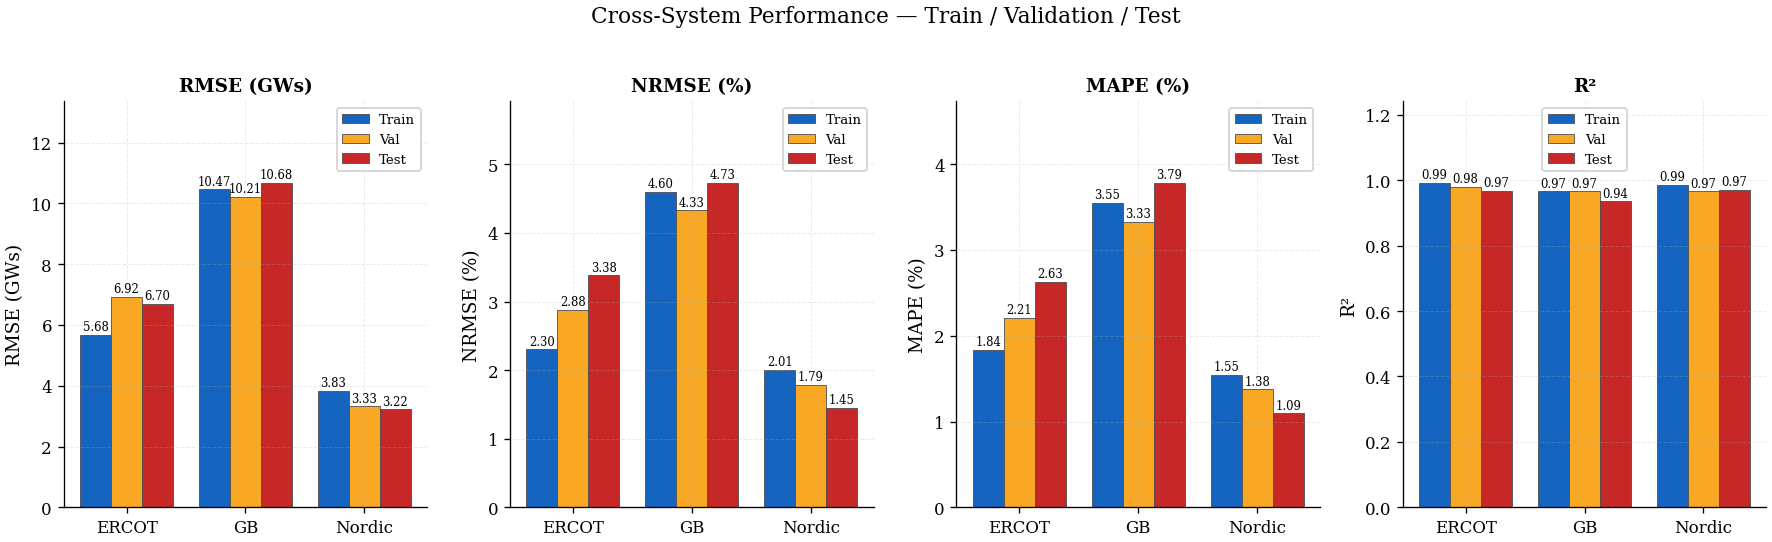

In [30]:
# ── Metrics table ─────────────────────────────────────────────────────────
rows = []
for sname in ['ERCOT','GB','Nordic']:
    for sp_ in ['train','val','test']:
        m = all_metrics[sname][sp_]
        rows.append({'System': sname, 'Split': sp_.capitalize(),
                     'K*': best_K[sname],
                     'RMSE (GWs)': f"{m['rmse']/1e3:.2f}",
                     'MAE (GWs)':  f"{m['mae']/1e3:.2f}",
                     'MAPE (%)':   f"{m['mape']:.2f}",
                     'NRMSE (%)':  f"{m['nrmse']:.2f}",
                     'R2':         f"{m['r2']:.4f}"})
summary = pd.DataFrame(rows).set_index(['System','Split'])
print(summary.to_string())

# ── Grouped bar chart ─────────────────────────────────────────────────────
snames   = ['ERCOT','GB','Nordic']
splits_  = ['train','val','test']
sp_col   = {'train':'#1565C0','val':'#F9A825','test':'#C62828'}
x = np.arange(len(snames)); w = 0.26

metric_defs = [
    ('RMSE (GWs)', lambda m: m['rmse']/1e3),
    ('NRMSE (%)',  lambda m: m['nrmse']),
    ('MAPE (%)',   lambda m: m['mape']),
    ('R\u00b2',  lambda m: m['r2']),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))
for ax, (ylabel, fn) in zip(axes, metric_defs):
    all_vals = [fn(all_metrics[s][sp_]) for s in snames for sp_ in splits_]
    for i, sp_ in enumerate(splits_):
        vals = [fn(all_metrics[s][sp_]) for s in snames]
        bars = ax.bar(x + (i-1)*w, vals, w, color=sp_col[sp_],
                      edgecolor='0.3', linewidth=0.5, label=sp_.capitalize())
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.005*max(all_vals),
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(snames, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(ylabel, fontsize=11)
    ax.set_ylim(0, max(all_vals) * 1.25)
    ax.legend(fontsize=8)

fig.suptitle('Cross-System Performance \u2014 Train / Validation / Test',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/summary_metrics.png')
plt.show()

## 10 · Model Interpretation

This section explains **what the MIQP sparse regression model has learned** about the drivers of system inertia.

### Approach
Raw regression coefficients $\beta_j$ are in physical units (MWs per MW, etc.) and are not directly comparable across features.
To rank importance, we compute **standardised coefficients**:

$$\tilde{\beta}_j = \frac{\beta_j \cdot \sigma(\phi_j)}{\sigma(I)}$$

$\tilde{\beta}_j$ measures how many standard deviations of inertia change for a **one standard deviation increase** in feature $j$.
It is unit-free and comparable across features and systems.

We also compute the **operational sensitivity** — the change in inertia (GWs) for a +1 GW step change in each base variable, evaluated at the training-set mean (linearised for nonlinear transforms).

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────
def base_var_of(fname):
    for bv in ['load','wind','solar','other_gen']:
        if bv in fname: return bv
    if 'hour' in fname: return 'calendar_hour'
    if 'dow'  in fname: return 'calendar_dow'
    if 'month'in fname: return 'calendar_month'
    if 'lag'  in fname: return 'AR_lag'
    return fname

def transform_of(fname):
    if '^2'   in fname: return 'quadratic'
    if 'sqrt' in fname: return 'square-root'
    if 'log'  in fname: return 'logarithmic'
    if 'sin'  in fname or 'cos' in fname: return 'harmonic'
    if 'lag'  in fname: return 'AR'
    return 'linear'

def marginal_sensitivity(fname, beta_j, phi_mean_j):
    """Change in inertia (GWs) for a +1 GW (+1000 MW) step in the base variable."""
    x = phi_mean_j
    if '^2'   in fname: delta_phi = 2 * x * 1000            # d(x^2)/dx * 1000
    elif 'sqrt' in fname: delta_phi = 1000 / (2*np.sqrt(x).clip(1e-6))  # d(sqrt(x))/dx * 1000
    elif 'log' in fname:  delta_phi = 1000 / (x + 1.0)      # d(log(x+eps))/dx * 1000
    elif 'sin' in fname or 'cos' in fname: delta_phi = 1.0   # unitless
    elif 'lag' in fname:  delta_phi = 1000.0                 # 1 GW lag change
    else:                 delta_phi = 1000.0                 # linear: 1 GW
    return beta_j * delta_phi / 1e3   # → GWs


# ─────────────────────────────────────────────────────────────────────────────
# Compute standardised coefficients and sensitivities
# ─────────────────────────────────────────────────────────────────────────────
interp = {}   # {sname: DataFrame with one row per selected feature}

for sname in ['ERCOT','GB','Nordic']:
    p    = final_params[sname]
    sp   = splits[sname]
    fn   = feat_data[sname]['feat_names']
    sel  = p['selected']

    phi_std  = sp['Phi_tr'].std(axis=0).clip(1e-8)
    phi_mean = sp['Phi_tr'].mean(axis=0)
    I_std    = sp['I_tr'].std()

    rows = []
    for j in sel:
        b_j    = p['beta'][j]
        std_c  = b_j * phi_std[j] / I_std           # standardised coeff
        sens   = marginal_sensitivity(fn[j], b_j, phi_mean[j])
        rows.append({
            'Feature':     fn[j],
            'Base var':    base_var_of(fn[j]),
            'Transform':   transform_of(fn[j]),
            'beta (raw)':  b_j,
            'std_coeff':   std_c,
            'sens_GW_per_GW': sens,
            'sign':        '+' if b_j > 0 else '-',
        })
    df_i = pd.DataFrame(rows).sort_values('std_coeff', key=abs, ascending=False)
    interp[sname] = df_i


# ─────────────────────────────────────────────────────────────────────────────
# Figure 1: Per-system standardised coefficient bar charts
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, sname in zip(axes, ['ERCOT','GB','Nordic']):
    df_i  = interp[sname]
    col   = PALETTE[sname]
    feats = df_i['Feature'].tolist()
    vals  = df_i['std_coeff'].values
    ypos  = np.arange(len(feats))
    bar_c = [col if v > 0 else '#C62828' for v in vals]

    bars = ax.barh(ypos, vals, color=bar_c, edgecolor='0.3',
                   linewidth=0.5, height=0.65)
    ax.set_yticks(ypos)
    ax.set_yticklabels(feats, fontsize=9)
    ax.axvline(0, color='k', linewidth=0.9)

    # Value labels on bars
    for bar, v in zip(bars, vals):
        xoff = 0.01 if v >= 0 else -0.01
        ha   = 'left' if v >= 0 else 'right'
        ax.text(v + xoff, bar.get_y() + bar.get_height()/2,
                f'{v:+.3f}', va='center', ha=ha, fontsize=8)

    ax.set_xlabel('Standardised coefficient $\\tilde{\\beta}_j$', fontsize=11)
    ax.set_title(
        f'{sname}  |  $K^\\star={len(feats)}$  |  '
        f'Test $R^2$={all_metrics[sname]["test"]["r2"]:.4f}',
        fontsize=11)
    ax.invert_yaxis()   # most important at top

    # Light horizontal bands for readability
    for y in ypos[::2]:
        ax.axhspan(y - 0.5, y + 0.5, color='0.95', zorder=0)

fig.suptitle(
    'Feature Importance — Standardised Regression Coefficients\n'
    '(positive = more inertia, negative = less inertia)',
    fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/feature_importance.png')
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Figure 2: Cross-system heatmap of standardised coefficients
# ─────────────────────────────────────────────────────────────────────────────
p_dim = len(feat_data['ERCOT']['feat_names'])   # =24
fn_all = feat_data['ERCOT']['feat_names']
hmap = np.zeros((p_dim, 3))

for col_idx, sname in enumerate(['ERCOT','GB','Nordic']):
    p  = final_params[sname]
    sp = splits[sname]
    fn = feat_data[sname]['feat_names']
    phi_std = sp['Phi_tr'].std(axis=0).clip(1e-8)
    I_std   = sp['I_tr'].std()
    for j in p['selected']:
        hmap[j, col_idx] = p['beta'][j] * phi_std[j] / I_std

# Sort rows by max absolute value across systems
row_max  = np.abs(hmap).max(axis=1)
sort_idx = np.argsort(row_max)[::-1]
# Keep only rows with at least one non-zero entry
nonzero  = sort_idx[row_max[sort_idx] > 0]
hmap_s   = hmap[nonzero, :]
labels_s = [fn_all[i] for i in nonzero]

vmax = np.abs(hmap_s).max() * 1.05
fig, ax = plt.subplots(figsize=(6, max(4, 0.42 * len(labels_s) + 1.5)))
im = ax.imshow(hmap_s, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['ERCOT','GB','Nordic'], fontsize=11)
ax.set_yticks(range(len(labels_s)))
ax.set_yticklabels(labels_s, fontsize=9)

# Annotate cells
for i in range(hmap_s.shape[0]):
    for j in range(3):
        v = hmap_s[i, j]
        if abs(v) > 0.001:
            tc = 'white' if abs(v) > 0.3 * vmax else 'black'
            ax.text(j, i, f'{v:+.3f}', ha='center', va='center',
                    fontsize=8, color=tc, fontweight='bold')
        else:
            ax.text(j, i, '—', ha='center', va='center',
                    fontsize=8, color='0.6')

cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Standardised coefficient $\\tilde{\\beta}_j$', fontsize=10)

ax.set_title(
    'Cross-System Feature Importance Heatmap\n'
    '(red = positive, blue = negative, \u2014 = not selected)',
    fontsize=12)
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/feature_heatmap.png')
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Figure 3: Operational sensitivity — GWs of inertia per +1 GW base variable
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, sname in zip(axes, ['ERCOT','GB','Nordic']):
    df_i  = interp[sname]
    feats = df_i['Feature'].tolist()
    vals  = df_i['sens_GW_per_GW'].values
    ypos  = np.arange(len(feats))
    bar_c = [PALETTE[sname] if v > 0 else '#C62828' for v in vals]

    bars = ax.barh(ypos, vals, color=bar_c, edgecolor='0.3',
                   linewidth=0.5, height=0.65)
    ax.set_yticks(ypos)
    ax.set_yticklabels(feats, fontsize=9)
    ax.axvline(0, color='k', linewidth=0.9)

    for bar, v in zip(bars, vals):
        xoff = 0.003 * (ax.get_xlim()[1] - ax.get_xlim()[0]) if ax.get_xlim()[1] != ax.get_xlim()[0] else 0.01
        ha   = 'left' if v >= 0 else 'right'
        ax.text(v, bar.get_y() + bar.get_height()/2,
                f'  {v:+.3f}', va='center', ha='left' if v >= 0 else 'right',
                fontsize=8)

    ax.set_xlabel('\u0394 Inertia (GWs) per +1 GW base variable', fontsize=10)
    ax.set_title(sname, fontsize=11)
    ax.invert_yaxis()
    for y in ypos[::2]:
        ax.axhspan(y - 0.5, y + 0.5, color='0.95', zorder=0)

fig.suptitle(
    'Operational Sensitivity — Inertia Change per +1 GW Base Variable\n'
    '(linearised at training-set mean for nonlinear transforms)',
    fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/operational_sensitivity.png')
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Detailed textual interpretation report
# ─────────────────────────────────────────────────────────────────────────────
DOMAIN = {
    'load':         'System load (demand). Higher load forces more synchronous '
                    'generators online, directly increasing rotational inertia.',
    'wind':         'Wind generation. Wind displaces synchronous units, reducing '
                    'inertia. Negative coefficients confirm this displacement effect.',
    'solar':        'Solar PV generation. Effect is system-dependent: confounded '
                    'with load seasonality (ERCOT summer-peak vs Nordic winter-peak).',
    'other_gen':    'Non-wind/non-solar generation (dominantly synchronous). '
                    'Direct physical contributor to rotational inertia.',
    'calendar_hour':'Hour-of-day encoding. Captures diurnal load/generation cycles '
                    'not fully explained by the forecast variables.',
    'calendar_dow': 'Day-of-week encoding. Captures weekday vs weekend commitment patterns.',
    'calendar_month':'Month encoding. Captures seasonal inertia patterns beyond load.',
    'AR_lag':       'Autoregressive inertia lag. Inertia is persistent: the previous '
                    "hour's or previous day's inertia is a strong predictor.",
}
TRANSFORM_INTERP = {
    'linear':      'linear relationship',
    'quadratic':   'accelerating (convex) relationship',
    'square-root': 'diminishing-returns (concave) relationship',
    'logarithmic': 'saturation-type (log-compressive) relationship',
    'harmonic':    'cyclic / seasonal pattern',
    'AR':          'temporal persistence (autoregressive)',
}

print('\n' + '\u2550'*70)
print('  MODEL INTERPRETATION REPORT')
print('\u2550'*70)

for sname in ['ERCOT','GB','Nordic']:
    m_te  = all_metrics[sname]['test']
    df_i  = interp[sname]
    K_star= best_K[sname]

    print(f'\n\u250c{"\u2500"*68}\u2510')
    print(f'\u2502  System: {sname:<10} K\u2605={K_star}  '
          f'Test R\u00b2={m_te["r2"]:.4f}  '
          f'RMSE={m_te["rmse"]/1e3:.2f} GWs  '
          f'MAPE={m_te["mape"]:.2f}%')
    print(f'\u2514{"\u2500"*68}\u2518')

    for rank, (_, row) in enumerate(df_i.iterrows(), start=1):
        sc   = row['std_coeff']
        sens = row['sens_GW_per_GW']
        dom  = DOMAIN.get(row['Base var'], 'Operational variable.')
        tfm  = TRANSFORM_INTERP.get(row['Transform'], row['Transform'])
        direction = 'INCREASES' if sc > 0 else 'DECREASES'

        print(f'\n  Rank {rank}: {row["Feature"]}  '
              f'(std coeff = {sc:+.4f}  |  '
              f'\u0394I = {sens:+.3f} GWs per +1 GW)')
        print(f'    Transform:  {tfm}')
        print(f'    Effect:     A 1-\u03c3 increase in this feature {direction} '
              f'inertia by {abs(sc):.4f} \u03c3 units ({abs(sc)*all_metrics[sname]["train"]["rmse"]/1e3:.2f} GWs approx.)')
        print(f'    Domain:     {dom}')

    # Cross-system note
    print(f'\n  Summary for {sname}:')
    top = df_i.iloc[0]
    print(f'  \u2022 Dominant driver: "{top["Feature"]}" '
          f'(std coeff {top["std_coeff"]:+.4f}) \u2192 {DOMAIN.get(top["Base var"],"")[:60]}')
    neg_mask = df_i['std_coeff'] < 0
    if neg_mask.any():
        neg_feats = df_i.loc[neg_mask, 'Feature'].tolist()
        print(f'  \u2022 Inertia-reducing features: {", ".join(neg_feats)}')
    else:
        print(f'  \u2022 All selected features have positive contributions.')
    ar_mask = df_i['Base var'] == 'AR_lag'
    if ar_mask.any():
        ar_c = df_i.loc[ar_mask, 'std_coeff'].values[0]
        print(f'  \u2022 Autoregressive persistence: lag std coeff = {ar_c:+.4f} '
              f'(inertia is {"highly" if abs(ar_c)>0.3 else "moderately"} persistent hour-to-hour)')

print('\n' + '\u2550'*70)
print('\n  KEY CROSS-SYSTEM FINDINGS')
print('\u2550'*70)
# Which features appear in all 3 systems?
sel_sets = {s: set(feat_data[s]['feat_names'][j] for j in final_params[s]['selected'])
            for s in ['ERCOT','GB','Nordic']}
common = sel_sets['ERCOT'] & sel_sets['GB'] & sel_sets['Nordic']
ercot_only = sel_sets['ERCOT'] - sel_sets['GB'] - sel_sets['Nordic']
gb_only    = sel_sets['GB']    - sel_sets['ERCOT'] - sel_sets['Nordic']
nordic_only= sel_sets['Nordic']- sel_sets['ERCOT'] - sel_sets['GB']
print(f'\n  Features common to ALL 3 systems: '
      f'{", ".join(sorted(common)) if common else "none"}')
print(f'  ERCOT-exclusive features:  '
      f'{", ".join(sorted(ercot_only)) if ercot_only else "none"}')
print(f'  GB-exclusive features:     '
      f'{", ".join(sorted(gb_only)) if gb_only else "none"}')
print(f'  Nordic-exclusive features: '
      f'{", ".join(sorted(nordic_only)) if nordic_only else "none"}')
# Sign of wind coefficient
print('\n  Wind coefficient signs (expected negative = displaces sync. gen.):')
for sname in ['ERCOT','GB','Nordic']:
    df_i = interp[sname]
    wind_rows = df_i[df_i['Base var'] == 'wind']
    if len(wind_rows):
        for _, r in wind_rows.iterrows():
            print(f'    {sname}: {r["Feature"]:20s} std_coeff={r["std_coeff"]:+.4f} '
                  f'({"as expected" if r["std_coeff"]<0 else "positive — confounding possible"})')
    else:
        print(f'    {sname}: wind not selected (K too small or collinearity exclusion)')
# Sync gen coefficient
print('\n  Other-gen coefficient signs (expected positive = synchronous inertia):')
for sname in ['ERCOT','GB','Nordic']:
    df_i = interp[sname]
    og_rows = df_i[df_i['Base var'] == 'other_gen']
    if len(og_rows):
        for _, r in og_rows.iterrows():
            print(f'    {sname}: {r["Feature"]:20s} std_coeff={r["std_coeff"]:+.4f} '
                  f'({"confirmed" if r["std_coeff"]>0 else "unexpected negative"} sign)')
    else:
        print(f'    {sname}: other_gen not selected')
print('\n' + '\u2550'*70)